<a href="https://colab.research.google.com/github/gabriela-abi/data-science-analytics-puc-rio/blob/main/MVP_ML_Analytics_20261.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Gabriela Oliveira Abi Chahin de Lima Gonçalves

**Matrícula:** 4052026000076

**Data:** 02/07/2026

**Dataset:** [The Movie Database](https://www.kaggle.com/datasets/rishabhkumar2003/the-movie-database-tmdb-comprehensive-dataset)

**Tipo de problema:** Regressão




# 1. Definição do problema

## 1.1 Descrição do problema

O sucesso na indústria cinematográfica envolve decisões estratégicas relacionadas a orçamento, marketing e planejamento de lançamentos, que podem impactar diretamente o desempenho financeiro de um filme. Neste projeto, estudaremos se um modelo de aprendizado de máquina é capaz de prever o faturamento de um filme com base no orçamento de produção e o mês de lançamento. Dessa forma, o problema é tratado como uma tarefa de regressão supervisionada, na qual o objetivo é estimar um valor numérico contínuo correspondente à receita obtida por uma produção cinematográfica.

Uma solução desse tipo pode ser útil para estúdios, produtoras, distribuidoras e investidores, auxiliando na avaliação do potencial comercial de novos projetos e apoiando decisões de negócio. A relevância do problema está na possibilidade de utilizar dados históricos para identificar padrões relacionados ao sucesso financeiro dos filmes, reduzindo incertezas e fornecendo estimativas que contribuam para um planejamento mais eficiente de futuras produções.



## 1.2 Objetivo do MVP

> O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever o faturamento de filmes a partir das características orçamento de produção e mês de lançamento, utilizando dados do dataset TMDb. Para isso, serão comparados um modelo baseline e modelos candidatos de regressão, analisando seu desempenho preditivo e suas limitações.



## 1.3 Tipo de problema

**Tipo escolhido:** Regressão

**Justificativa:** O objetivo do projeto é prever o faturamento (revenue) de um filme, que é uma variável numérica contínua expressa em valores monetários. Diferentemente de um problema de classificação, em que o modelo prevê categorias ou classes, neste caso busca-se estimar um valor quantitativo a partir de características como orçamento de produção e mês de lançamento. Portanto, o problema se enquadra como uma tarefa de regressão supervisionada, na qual o modelo aprende, a partir de exemplos históricos rotulados, a prever o faturamento de novos filmes.

## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**

1. Filmes com maior orçamento tendem a apresentar maior faturamento.
2. O mês de lançamento influencia o faturamento.
3. O orçamento é mais relevante para previsão do que o mês de lançamento.

**Critérios de sucesso:**

* **Métrica principal:** RMSE (*Root Mean Squared Error*), complementada pelo coeficiente de determinação (R²).
* **Resultado mínimo esperado:** obter desempenho superior ao modelo baseline, reduzindo o RMSE em pelo menos 10% e apresentando um valor de R² positivo.
* **Restrição prática:** o modelo deve possuir baixo custo computacional e ser suficientemente interpretável para permitir a análise da influência das variáveis utilizadas na previsão do faturamento.

> Para este problema, um modelo será considerado bem-sucedido se conseguir prever o faturamento com erro inferior ao baseline e capturar parte da variabilidade dos dados por meio de um R² positivo, mantendo simplicidade e facilidade de interpretação dos resultados.



# 2. Ambiente, bibliotecas e reprodutibilidade


In [ ]:
# === Setup básico e reprodutibilidade ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random
import sys
import time

from matplotlib.ticker import FuncFormatter, MultipleLocator
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from scipy.stats import randint
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)


Python: 3.12.13
Seed: 42


## 2.2 Funções auxiliares

In [ ]:
def evaluate_regression(y_true, y_pred):
    """Calcula métricas básicas para regressão."""
    mse = mean_squared_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred),
        "MAPE (%)": mape

    }


def show_results_table(results_dict):
    """Exibe resultados como DataFrame ordenável."""
    return pd.DataFrame(results_dict).T

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

O dataset utilizado neste projeto tem como base dados do The Movie Database (TMDb), uma plataforma colaborativa que reúne informações sobre filmes, séries e profissionais da indústria audiovisual. A base foi escolhida por conter atributos diretamente relacionados ao problema proposto, como orçamento, faturamento e data de lançamento, além de já ter sido utilizada na etapa anterior de análise exploratória, permitindo dar continuidade ao estudo. Fonte: https://www.themoviedb.org/

Para a modelagem, foram considerados apenas os registros com informações válidas para as variáveis selecionadas, sendo necessárias etapas de pré-processamento para adequação dos dados aos algoritmos de machine learning. Não há questões relevantes de privacidade ou confidencialidade, pois o dataset é composto por informações públicas sobre produções cinematográficas e está sendo utilizado exclusivamente para fins acadêmicos e educacionais.


## 3.2 Carga dos dados


In [ ]:
# carregamento do dataset
df_movies = pd.read_csv('https://raw.githubusercontent.com/gabriela-abi/data-science-analytics-puc-rio/refs/heads/main/movies.csv', sep=',', engine='python')

## 3.3 Visão geral do dataset

O dataset utilizado possui 9.771 registros e 22 atributos, contendo informações relacionadas a filmes, como título, descrição, data de lançamento, orçamento, faturamento, avaliações e popularidade. A maior parte das variáveis é do tipo categórico/textual (*object*), enquanto apenas algumas são numéricas, incluindo orçamento (*budget*), faturamento (*revenue*) e duração (*runtime*). A análise inicial da qualidade dos dados mostrou ausência de registros duplicados e uma quantidade relativamente baixa de valores ausentes nas variáveis mais relevantes para a modelagem. As maiores concentrações de dados faltantes estão em campos descritivos, como *homepage*, *tagline* e imagens promocionais, que não serão utilizados na construção do modelo. Dessa forma, o dataset apresenta qualidade adequada para o desenvolvimento do projeto, exigindo apenas etapas pontuais de tratamento e pré-processamento dos dados.



In [ ]:
print("Formato do dataset:", df_movies.shape)
print("\nTipos de dados:")
display(df_movies.dtypes.to_frame("tipo"))

Formato do dataset: (9771, 22)

Tipos de dados:


,tipo
id,object
title,object
original_title,object
overview,object
release_date,object
runtime,float64
budget,float64
revenue,float64
vote_average,object
vote_count,object


In [ ]:
print("\nValores ausentes por coluna:")
display(df_movies.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
id,0
title,0
original_title,0
overview,160
release_date,61
runtime,1
budget,1
revenue,1
vote_average,1
vote_count,1


In [ ]:
print("\nDuplicatas:", df_movies.duplicated().sum())



Duplicatas: 0


In [ ]:
display(df_movies.sample(5, random_state=SEED))

,id,title,original_title,overview,release_date,runtime,budget,revenue,vote_average,vote_count,...,backdrop_path,status,tagline,homepage,original_language,adult,video,created_at,updated_at,genres
8373,1027269,This Is What I Remember,Esimde,An amnesiac old man Zarlyk who after twenty-th...,2023-09-21,105.0,0.0,0.0,0.0,0,...,/vQgFnDEXsSwebqMb0kt32V2DAeJ.jpg,Released,NaN,NaN,ky,0,0,2026-02-13 13:34:32,2026-02-13T19:04:32.156441,Drama
2523,43889,Bonnie Scotland,Bonnie Scotland,Stan and Ollie stow away to Scotland expecting...,1935-08-23,80.0,0.0,0.0,6.6,68,...,/o54BF6hXfz3sq3xG3DHtzyBnkl2.jpg,Released,60 minutes of fun!,NaN,en,0,0,2026-02-13 11:30:57,2026-02-13T17:00:57.015194,Comedy
5128,326530,Babacan,Babacan,Şahin is a successful police officer. Three ye...,1975-01-01,85.0,0.0,0.0,7.8,2,...,NaN,Released,NaN,NaN,tr,0,0,2026-02-13 12:25:57,2026-02-13T17:55:57.262630,"Action,Crime"
4489,245168,Suffragette,Suffragette,Based on true events about the foot soldiers o...,2015-10-16,106.0,14000000.0,16002420.0,7.197,1659,...,/mYzmWGhy9PZ6xUo0D4i3bBRdX2u.jpg,Released,Mothers. Daughters. Rebels.,NaN,en,0,0,2026-02-13 12:39:36,2026-02-13T18:09:36.941807,"Drama,History"
8774,1159311,My Hero Academia: You're Next,僕のヒーローアカデミア THE MOVIE ユアネクスト,In a society devastated by the effects of an a...,2024-08-02,110.0,0.0,32224616.0,7.212,193,...,/tUbwMOYP4cuGL1sQ0edz5943rBY.jpg,Released,Next up is you.,NaN,ja,0,0,2026-02-13 11:45:47,2026-02-13T17:15:47.516582,"Adventure,Animation,Action,Science Fiction"


## 3.4 Dicionário de dados

| Coluna            | Tipo                  | Descrição                                     | Será usada no modelo? | Observações                                                                                                  |
| ----------------- | --------------------- | --------------------------------------------- | --------------------- | ------------------------------------------------------------------------------------------------------------ |
| id                | Categórica            | Identificador único do filme.                 | Não                   | Não possui valor preditivo para o faturamento.                                                               |
| title             | Texto                 | Título do filme.                              | Não                   | Informação descritiva.                                                                                       |
| original_title    | Texto                 | Título original do filme.                     | Não                   | Informação descritiva.                                                                                       |
| overview          | Texto                 | Sinopse do filme.                             | Não                   | Exigiria técnicas de NLP para utilização.                                                                    |
| release_date      | Data                  | Data de lançamento do filme.                  | Não                   | Utilizada apenas para gerar a variável *release_month*.                                                      |
| runtime           | Numérica              | Duração do filme em minutos.                  | Não                   | Não foi considerada neste MVP.                                                                               |
| budget            | Numérica              | Orçamento de produção do filme.               | Sim                   | Principal variável explicativa; foi padronizada.                                                             |
| revenue           | Numérica              | Receita total obtida pelo filme.              | Alvo                  | Variável a ser prevista; recebeu transformação logarítmica (`log1p`).                                        |
| vote_average      | Numérica              | Média das avaliações dos usuários.            | Não                   | Não utilizada para evitar dependência de informações posteriores ao lançamento.                              |
| vote_count        | Numérica              | Quantidade de avaliações recebidas.           | Não                   | Pode refletir popularidade após o lançamento.                                                                |
| popularity        | Numérica              | Índice de popularidade calculado pelo TMDb.   | Não                   | Não foi utilizada neste MVP.                                                                                 |
| poster_path       | Texto                 | Caminho da imagem do pôster.                  | Não                   | Informação visual não explorada.                                                                             |
| backdrop_path     | Texto                 | Caminho da imagem de fundo do filme.          | Não                   | Informação visual não explorada.                                                                             |
| status            | Categórica            | Status da produção (Released, Planned etc.).  | Não                   | Pouca relevância para o objetivo do modelo.                                                                  |
| tagline           | Texto                 | Frase promocional do filme.                   | Não                   | Exigiria processamento de texto.                                                                             |
| homepage          | Texto                 | Site oficial do filme.                        | Não                   | Alto volume de valores ausentes.                                                                             |
| original_language | Categórica            | Idioma original do filme.                     | Não                   | Não utilizada neste MVP para simplificar a modelagem.                                                        |
| adult             | Categórica (booleana) | Indica conteúdo adulto.                       | Não                   | Baixa relevância para o objetivo do projeto.                                                                 |
| video             | Categórica (booleana) | Indica se o registro corresponde a um vídeo.  | Não                   | Não relacionada ao problema proposto.                                                                        |
| created_at        | Data                  | Data de criação do registro.                  | Não                   | Informação administrativa do dataset.                                                                        |
| updated_at        | Data                  | Data da última atualização do registro.       | Não                   | Informação administrativa do dataset.                                                                        |
| genres            | Categórica            | Gêneros associados ao filme.                  | Não                   | Foi analisada no MVP anterior, mas não utilizada neste modelo para manter simplicidade e interpretabilidade. |
| release_month     | Categórica            | Mês de lançamento extraído de *release_date*. | Sim                   | Transformada por one-hot encoding para representar sazonalidade.                                             |



## 3.5 Seleção e tratamento inicial dos dados
Para o MVP, trabalharemos apenas com filmes lançados entre 2000 e 2025 e com valores para budget e revenue não nulos ou 0.

In [ ]:
# 1. Cópia e Conversão Inicial
df_elegivel = df_movies.copy()

# Tratamento de dados numéricos (garantindo que strings inválidas virem NaN)
df_elegivel['budget'] = pd.to_numeric(df_elegivel['budget'], errors='coerce')
df_elegivel['revenue'] = pd.to_numeric(df_elegivel['revenue'], errors='coerce')

# 2. Tratamento de Datas (Antes da filtragem para evitar erros)
df_elegivel['release_date'] = pd.to_datetime(df_elegivel['release_date'], errors='coerce')

# 3. Definição de Elegibilidade (Máscara Booleana)
mask = (
    (df_elegivel['revenue'] > 0) &
    (df_elegivel['budget'] > 0) &
    (df_elegivel['release_date'].notna())
)

# Aplicando o filtro principal
df_filtered = df_elegivel[mask].copy()

# 4. Criação de Colunas Temporais e Financeiras
df_filtered['year'] = df_filtered['release_date'].dt.year
df_filtered['month'] = df_filtered['release_date'].dt.month

# Aplicando o filtro de período (2000-2025) sem destruir o DataFrame
df_filtered = df_filtered[(df_filtered['year'] >= 2000) & (df_filtered['year'] <= 2025)]

# Cálculos financeiros
df_filtered['profit'] = df_filtered['revenue'] - df_filtered['budget']
df_filtered['roi'] = df_filtered['revenue'] / df_filtered['budget']

# 5. Mapeamento de Meses
meses_pt = {
    1:'Jan', 2:'Fev', 3:'Mar', 4:'Abr', 5:'Mai', 6:'Jun',
    7:'Jul', 8:'Ago', 9:'Set', 10:'Out', 11:'Nov', 12:'Dez'
}
df_filtered['month_name'] = df_filtered['month'].map(meses_pt)

# 6. Ordenação de anos
df_filtered = df_filtered.sort_values('release_date')

# 4. Análise exploratória dos dados


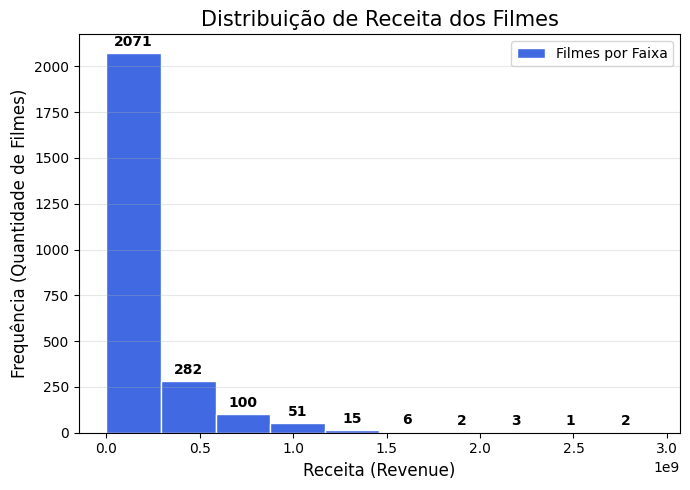

In [ ]:
plt.figure(figsize=(7, 5))

# 2. Configuração do gráfico
# 'label' para a legenda e guardamos o retorno em 'bars'
counts, bins, bars = plt.hist(df_filtered['revenue'], bins=10,
                              color='royalblue', edgecolor='white',
                              label='Filmes por Faixa')

# Função bar_label pra trazer rótulo de dados nas barras
ax = plt.gca()
ax.bar_label(bars, padding=3, fontsize=10, fontweight='bold', color='black')

# 3. Legenda, Labels e Títulos
plt.title('Distribuição de Receita dos Filmes', fontsize=15)
plt.xlabel('Receita (Revenue)', fontsize=12)
plt.ylabel('Frequência (Quantidade de Filmes)', fontsize=12)

# O comando que faz a legenda aparecer:
plt.legend(loc='upper right', frameon=True)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

O histograma de faturamento mostra uma distribuição altamente assimétrica à direita, indicando que a maioria dos filmes possui baixo faturamento, enquanto poucos filmes concentram receitas extremamente altas.

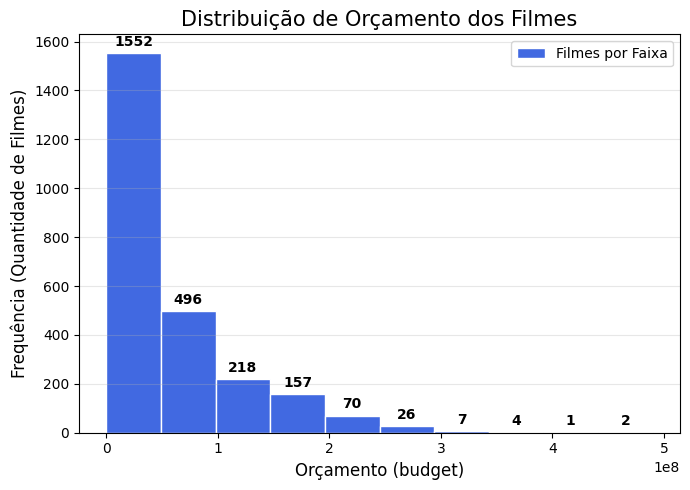

In [ ]:
plt.figure(figsize=(7, 5))

# 2. Configuração do gráfico
# 'label' para a legenda e guardamos o retorno em 'bars'
counts, bins, bars = plt.hist(df_filtered['budget'], bins=10,
                              color='royalblue', edgecolor='white',
                              label='Filmes por Faixa')

# Função bar_label pra trazer rótulo de dados nas barras
ax = plt.gca()
ax.bar_label(bars, padding=3, fontsize=10, fontweight='bold', color='black')

# 3. Legenda, Labels e Títulos
plt.title('Distribuição de Orçamento dos Filmes', fontsize=15)
plt.xlabel('Orçamento (budget)', fontsize=12)
plt.ylabel('Frequência (Quantidade de Filmes)', fontsize=12)

# O comando que faz a legenda aparecer:
plt.legend(loc='upper right', frameon=True)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Assim como visto no faturamento, o histograma de orçamento também mostra uma distribuição assimétrica para a direita, demonstrando que grande parte dos filmes possui baixo orçamento.

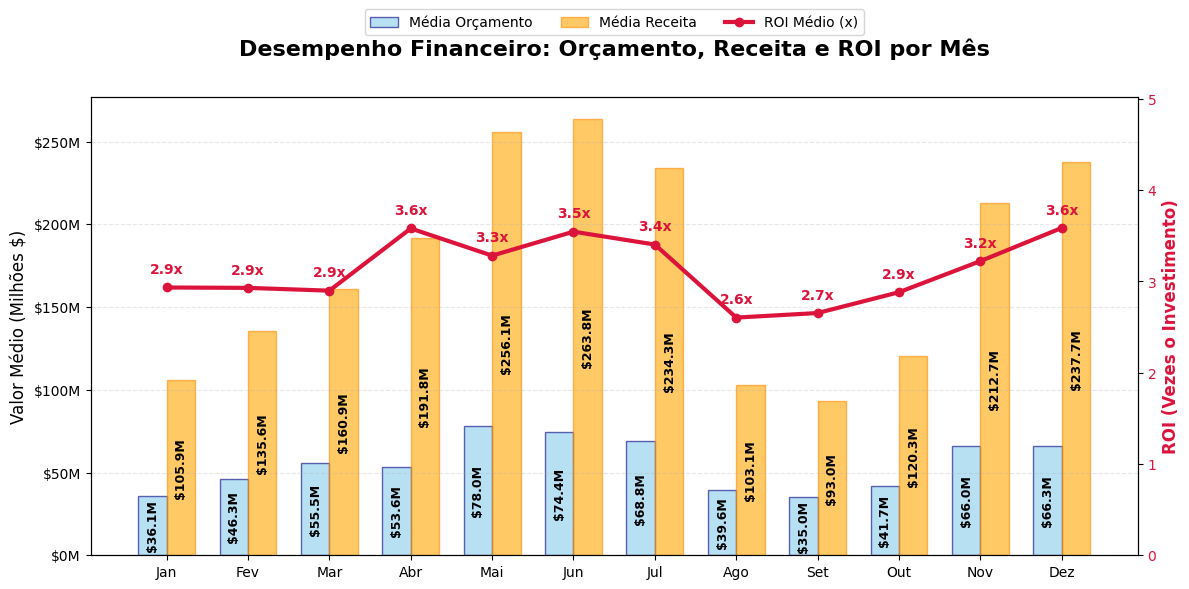

In [ ]:
# --- 1. Preparação dos dados ---
# Agrupando e garantindo que todos os 12 meses existam
df_month_avg = df_filtered.groupby('month')[['budget', 'revenue']].mean().reset_index()
df_month_avg = df_month_avg.sort_values('month')

# Cálculo do ROI Médio por mês
df_month_avg['roi'] = df_month_avg['revenue'] / df_month_avg['budget']

# --- 2. CONFIGURAÇÃO DO GRÁFICO ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# DEFINIÇÃO DAS VARIÁVEIS FALTANTES
meses_labels = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
x = np.arange(len(meses_labels)) # Define as posições 0 a 11
largura_barra = 0.35

# --- BARRAS (Eixo Y Esquerdo - Dinheiro) ---
bars_budget = ax1.bar(x - largura_barra/2, df_month_avg['budget'], largura_barra,
                      label='Média Orçamento', color='skyblue', edgecolor='navy', alpha=0.6)

bars_revenue = ax1.bar(x + largura_barra/2, df_month_avg['revenue'], largura_barra,
                       label='Média Receita', color='orange', edgecolor='darkorange', alpha=0.6)

# --- LINHA DE ROI (Eixo Y Direito - Multiplicador) ---
ax2 = ax1.twinx()
# O label aqui precisa ser uma lista para o legend() funcionar depois
line_roi = ax2.plot(x, df_month_avg['roi'], color='crimson', marker='o',
                    linewidth=3, label='ROI Médio (x)')

# Adicionando rótulos de texto na linha de ROI
for i, val in enumerate(df_month_avg['roi']):
    ax2.annotate(f'{val:.1f}x', (x[i], df_month_avg['roi'].iloc[i]),
                 textcoords="offset points", xytext=(0,10), ha='center',
                 color='crimson', fontweight='bold')

# --- 3. FORMATAÇÃO ---
def millions(x, pos):
    return f'${x / 1e6:.0f}M'

ax1.yaxis.set_major_formatter(FuncFormatter(millions))
ax2.set_ylabel('ROI (Vezes o Investimento)', color='crimson', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.set_ylim(0, df_month_avg['roi'].max() * 1.4) # Espaço para rótulos

# Função para adicionar rótulos nas barras (Melhorada para legibilidade)
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height/2,
                 f'${height/1e6:.1f}M',
                 ha='center', va='center', rotation=90,
                 color='black', fontweight='bold', fontsize=9)

add_labels(bars_budget)
add_labels(bars_revenue)

# --- 4. Títulos e Legendas ---
ax1.set_title('Desempenho Financeiro: Orçamento, Receita e ROI por Mês', fontsize=16, fontweight='bold', pad=30)
ax1.set_ylabel('Valor Médio (Milhões $)', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(meses_labels)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Unindo as legendas de eixos diferentes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower center',
           bbox_to_anchor=(0.5, 1.12), ncol=3, frameon=True)

plt.tight_layout()
plt.show()

Com esse gráfico, observamos que o mercado cinematográfico opera em dois ciclos: o ciclo de escala (Maio/Junho), onde o faturamento é maximizado pelo alto investimento, e o ciclo de eficiência (Abril/Dezembro), onde o retorno sobre o capital é otimizado. Fora desses eixos, como visto em Agosto e Setembro, a redução drástica de custos não se traduz em segurança, mas sim em uma queda acentuada na capacidade de geração de receita. Com os menores investimentos médios do ano, a receita despenca proporcionalmente, resultando no menor ROI do dataset (2.6x - 2.7x). Isso prova que o baixo investimento inicial nestes meses atua como um teto de vidro: sem o "combustível" do orçamento de produção e marketing, os filmes não conseguem gerar a tração necessária para romper a barreira da estagnação comercial. O faturamento médio flutua mais de 180% entre o pior mês (Setembro) e o melhor (Junho), validando a hipótese de que o mês de lançamento é crucial.

Top 5 zonas de maior densidade (maiores bolhas):
Faixa: Budget ~$0M | Revenue ~$0M -> 257 filmes
Faixa: Budget ~$10M | Revenue ~$0M -> 200 filmes
Faixa: Budget ~$20M | Revenue ~$0M -> 132 filmes
Faixa: Budget ~$20M | Revenue ~$50M -> 123 filmes
Faixa: Budget ~$10M | Revenue ~$50M -> 93 filmes


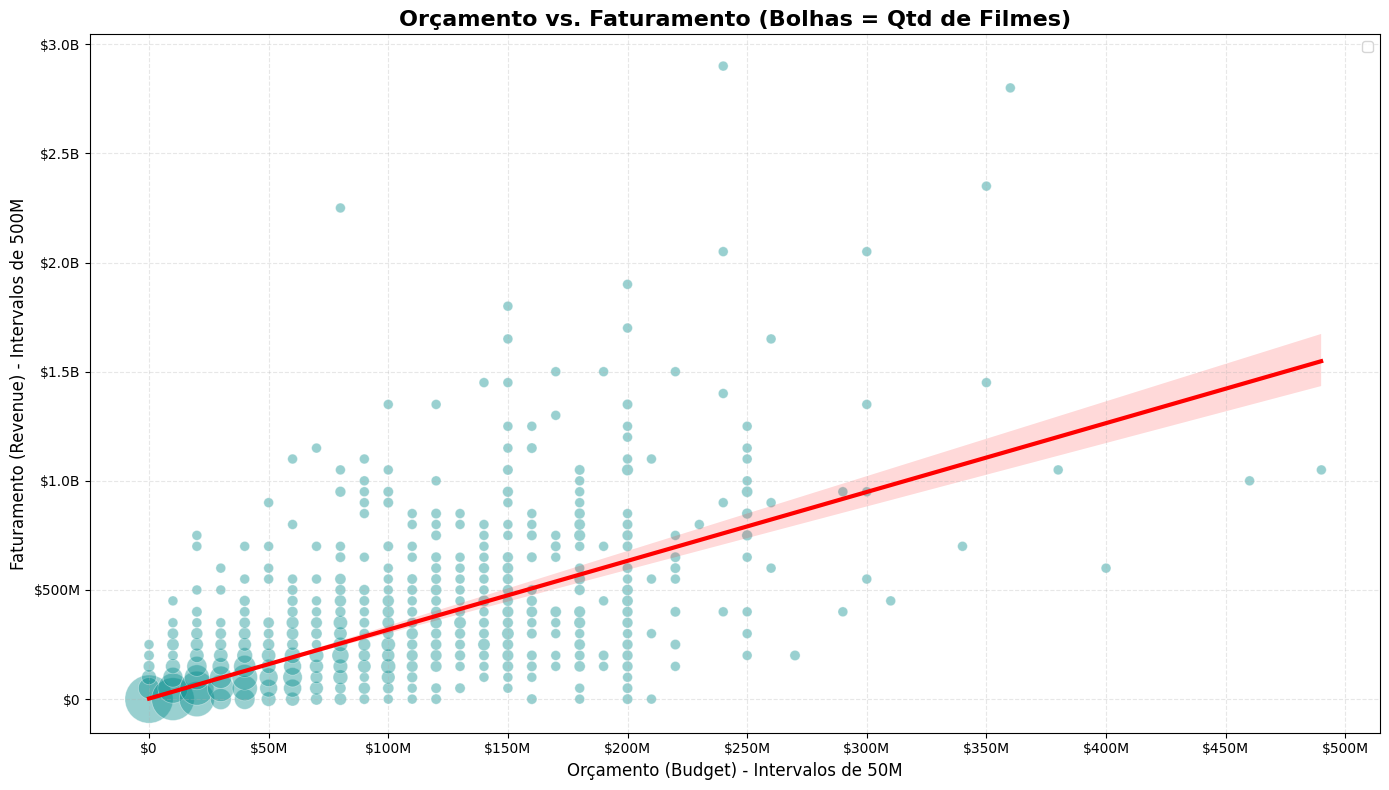

In [ ]:
# 1. Agrupamento para definir o tamanho das bolinhas (Bubble Chart)
df_bubbles = df_filtered.copy()
# Criando faixas para agrupar filmes com valores próximos
df_bubbles['budget_bin'] = (df_bubbles['budget'] / 1e7).round() * 1e7 # Tamanho do Bin de Orçamento: $10M
df_bubbles['revenue_bin'] = (df_bubbles['revenue'] / 5e7).round() * 5e7 # Tamanho do Bin de Faturamento: $50M

df_counts_for_bubble = df_bubbles.groupby(['budget_bin', 'revenue_bin']).size().reset_index(name='movie_count')

top_bins = df_counts_for_bubble.sort_values('movie_count', ascending=False).head(5)
print("Top 5 zonas de maior densidade (maiores bolhas):")
for i, row in top_bins.iterrows():
    print(f"Faixa: Budget ~${row['budget_bin']/1e6:.0f}M | Revenue ~${row['revenue_bin']/1e6:.0f}M -> {int(row['movie_count'])} filmes")

# 2. Configuração do Gráfico
plt.figure(figsize=(14, 8))

# Scatter com tamanho proporcional à contagem
sns.scatterplot(data=df_counts_for_bubble, x='budget_bin', y='revenue_bin',
                size='movie_count', sizes=(50, 1200), alpha=0.4,
                color='darkcyan', edgecolor='white', legend=None)

# Linha de tendência (sem desenhar os pontos originais para não sobrepor)
sns.regplot(data=df_filtered, x='budget', y='revenue',
            scatter=False, color='red', line_kws={'linewidth': 3, 'label': 'Tendência Linear'})

# --- AJUSTE DAS ESCALAS (Ticks) ---
# Eixo Y a cada 500M
plt.gca().yaxis.set_major_locator(MultipleLocator(500000000))
# Eixo X a cada 50M
plt.gca().xaxis.set_major_locator(MultipleLocator(50000000))

# 3. Formatação dos Eixos (Legível em M e B)
def millions_billions(x, pos):
    if abs(x) >= 1e9: return f'${x/1e9:.1f}B'
    if abs(x) >= 1e6: return f'${x/1e6:.0f}M'
    return f'${x:.0f}'

plt.gca().yaxis.set_major_formatter(FuncFormatter(millions_billions))
plt.gca().xaxis.set_major_formatter(FuncFormatter(millions_billions))

# 4. Títulos e Estética
plt.title('Orçamento vs. Faturamento (Bolhas = Qtd de Filmes)', fontsize=16, fontweight='bold')
plt.xlabel('Orçamento (Budget) - Intervalos de 50M', fontsize=12)
plt.ylabel('Faturamento (Revenue) - Intervalos de 500M', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Como observamos nesse gráfico e no gráfico de desempenho financeiro por mês, a grande maioria dos filmes com orçamento próximo de \$0 até \$100M está "presa" na base do gráfico, raramente ultrapassando a marca dos $500M de faturamento. O Bubble Plot mostra que, sem investimento, as chances de um filme "furar a bolha" e chegar aos bilhões são estatisticamente irrelevantes. Não existe nenhum ponto no gráfico que tenha Budget até \$50M e Revenue > \$1B

## 4.1 Síntese da análise exploratória
A análise exploratória mostrou que tanto o faturamento quanto o orçamento dos filmes apresentam uma distribuição altamente assimétrica, com poucos títulos concentrando receitas muito elevadas. Além disso, foi identificada uma relação positiva entre orçamento e faturamento, indicando que produções com maiores investimentos tendem a alcançar maiores receitas.

Também foi observado que o mês de lançamento influencia o desempenho financeiro dos filmes, com variações superiores a 180% no faturamento médio entre os períodos de melhor e pior desempenho. Além disso, a análise sugere uma correlação positiva entre orçamento e faturamento e reforça a hipótese de que filmes com baixos orçamentos raramente alcançam receitas extremamente altas.

Por fim, a análise de qualidade dos dados mostrou ausência de registros duplicados e poucos valores ausentes nas variáveis utilizadas na modelagem



# 5. Preparação dos dados e divisão treino/teste

| Etapa                             | Situação                                        |
| --------------------------------- | ----------------------------------------------- |
| Seleção das features              | ✅ `budget` e `month`                            |
| Definição do target               | ✅ `revenue` (transformado com `log1p`)          |
| One-hot encoding                  | ✅ Aplicado em `month`                           |
| Padronização                      | ✅ Aplicada em `budget`                          |
| Divisão treino/teste              | ✅ Realizada antes da padronização               |
| Remoção de atributos irrelevantes | ✅ Feita ao selecionar apenas `budget` e `month` |



In [ ]:
# Separar features (X) e target (y)
X = df_filtered[['budget', 'month']]
y = np.log1p(df_filtered['revenue'])

Foi aplicada a transformação logarítmica na variável de faturamento utilizando np.log1p, com o objetivo de reduzir a assimetria da distribuição e o impacto de valores extremos. Como observado na análise exploratória, o faturamento apresenta uma distribuição altamente enviesada à direita, com poucos filmes concentrando receitas muito elevadas. A aplicação do log torna a distribuição mais próxima de uma normal, facilitando o aprendizado do modelo e melhorando sua capacidade de generalização.

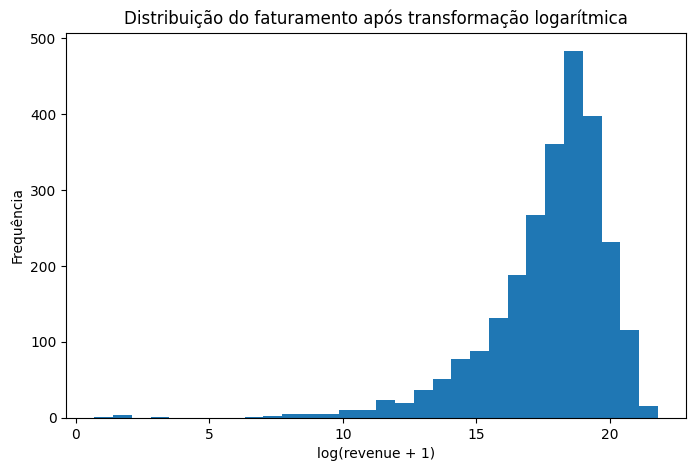

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(y, bins=30)
plt.title("Distribuição do faturamento após transformação logarítmica")
plt.xlabel("log(revenue + 1)")
plt.ylabel("Frequência")
plt.show()

A aplicação da transformação logarítmica (`log1p`) reduziu significativamente a assimetria da variável de faturamento. Antes da transformação, a distribuição era fortemente enviesada à direita, com poucos filmes concentrando receitas extremamente elevadas e influenciando a escala dos dados. Após a transformação, os valores passaram a apresentar uma distribuição mais concentrada e próxima da normalidade, reduzindo o impacto dos outliers e tornando a variável mais adequada para a construção de modelos de regressão. Embora ainda exista uma leve assimetria, a distribuição resultante é significativamente mais equilibrada, favorecendo o processo de aprendizado do modelo.

In [ ]:
X = pd.get_dummies(X, columns=['month'], drop_first=True)

A variável de mês de lançamento foi transformada utilizando one-hot encoding por meio da função get_dummies. Essa abordagem converte a variável categórica em um conjunto de variáveis binárias, permitindo que o modelo trate cada mês de forma independente, sem assumir uma relação ordinal entre eles. O parâmetro `drop_first=True` foi utilizado para evitar multicolinearidade, removendo uma das categorias de referência e garantindo estabilidade no modelo de regressão. Sem essa configuração, as variáveis dummy seriam linearmente dependentes, já que a soma de todas elas é sempre igual a 1. Ao remover uma das categorias, estabelece-se uma categoria de referência (baseline), permitindo que o modelo interprete os coeficientes das demais variáveis como variações em relação a essa base, garantindo maior estabilidade e interpretabilidade dos resultados.

In [ ]:
# === Configuração do problema ===

TARGET = "revenue"
PROBLEM_TYPE = "regressao"

features = list(X.columns)

print(f"Tipo de problema: {PROBLEM_TYPE}")
print(f"Target: {TARGET}")
print(f"Número de features: {len(features)}")
print("Features:")
for feature in features:
    print("-", feature)

Tipo de problema: regressao
Target: revenue
Número de features: 12
Features:
- budget
- month_2
- month_3
- month_4
- month_5
- month_6
- month_7
- month_8
- month_9
- month_10
- month_11
- month_12


In [ ]:
# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED
)

print("Treino:", X_train.shape, "| Teste:", X_test.shape)

Treino: (2026, 12) | Teste: (507, 12)


In [ ]:
print("Valores ausentes:")
print(X_train.isnull().sum())

print("\nTipos de dados:")
print(X_train.dtypes)

Valores ausentes:
budget      0
month_2     0
month_3     0
month_4     0
month_5     0
month_6     0
month_7     0
month_8     0
month_9     0
month_10    0
month_11    0
month_12    0
dtype: int64

Tipos de dados:
budget      float64
month_2        bool
month_3        bool
month_4        bool
month_5        bool
month_6        bool
month_7        bool
month_8        bool
month_9        bool
month_10       bool
month_11       bool
month_12       bool
dtype: object


## 5.1 Justificativa da divisão

**Resposta:**  
> A divisão dos dados foi realizada utilizando a estratégia de **holdout**, separando aproximadamente 80% das observações para treinamento (2.026 registros) e 20% para teste (507 registros). Essa abordagem é adequada para o tamanho do dataset, que possui mais de 2.500 observações após o tratamento dos dados, permitindo que o modelo seja treinado com uma quantidade suficiente de exemplos e, ao mesmo tempo, avaliado em um conjunto independente.

>Como o problema é de **regressão**, não foi necessária a estratificação das amostras, uma vez que não existem classes a serem balanceadas. Também não foi utilizada uma divisão temporal, pois o objetivo do projeto não é realizar previsão futura em séries temporais, mas sim identificar padrões gerais entre as características dos filmes e seu faturamento. Além disso, a divisão entre treino e teste foi realizada antes do processo de padronização, garantindo que os parâmetros de transformação fossem calculados apenas com os dados de treinamento e posteriormente aplicados ao conjunto de teste. Essa prática evita vazamento de dados (*data leakage*), assegurando que a avaliação do modelo represente seu desempenho em dados não vistos durante o treinamento.



# 6. Pré-processamento e pipeline

In [ ]:
# Padronização apenas da variável budget
scaler = StandardScaler()

X_train['budget'] = scaler.fit_transform(X_train[['budget']])
X_test['budget'] = scaler.transform(X_test[['budget']])

## 6.1 Decisões de pré-processamento

Esse trecho realiza a padronização da variável budget utilizando o StandardScaler. Inicialmente, o método fit_transform() é aplicado apenas aos dados de treinamento, calculando a média e o desvio padrão do orçamento e transformando os valores para uma escala com média 0 e desvio padrão 1. Em seguida, o método transform() aplica essa mesma transformação ao conjunto de teste, utilizando os parâmetros aprendidos no treinamento. Esse procedimento evita vazamento de dados (data leakage) e garante que ambas as bases estejam na mesma escala, favorecendo o desempenho de modelos sensíveis à magnitude das variáveis, como a Regressão Linear.



# 7. Baseline e modelos candidatos


In [ ]:
passthrough_step = FunctionTransformer(lambda x: x)

# 1. Definição do Baseline e Modelos Candidatos com Pipeline

baseline = Pipeline(steps=[
    ("preprocess", passthrough_step),
    ("model", DummyRegressor(strategy="mean"))
])

candidates = {
    "LinearRegression": Pipeline(steps=[
        ("preprocess", passthrough_step),
        ("model", LinearRegression())
    ]),
    "RandomForestRegressor": Pipeline(steps=[
        ("preprocess", passthrough_step),
        ("model", RandomForestRegressor(random_state=SEED))
    ])
}

print("Modelos candidatos:", list(candidates.keys()))

Modelos candidatos: ['LinearRegression', 'RandomForestRegressor']


## 7.1 Justificativa dos modelos

**Resposta:**  
> O DummyRegressor foi escolhido como modelo baseline por representar uma estratégia simples de previsão, utilizando a média dos valores de faturamento do conjunto de treinamento. Como esse modelo não considera as variáveis de entrada, ele estabelece um desempenho mínimo esperado e permite verificar se os modelos de machine learning realmente conseguem aprender padrões presentes nos dados.

> Como primeiro modelo candidato, foi utilizada a Regressão Linear, por ser um algoritmo amplamente empregado em problemas de regressão e por oferecer alta interpretabilidade. Esse modelo permite avaliar se existe uma relação aproximadamente linear entre o orçamento, o mês de lançamento e o faturamento dos filmes. Além disso, por utilizar métodos baseados em distância e coeficientes, a Regressão Linear se beneficia da padronização da variável budget, enquanto o One-Hot Encoding aplicado ao mês de lançamento possibilita o tratamento adequado da variável categórica.

> O segundo modelo candidato foi o Random Forest Regressor, escolhido por sua capacidade de capturar relações não lineares e interações entre as variáveis preditoras. Diferentemente da Regressão Linear, esse algoritmo é baseado em árvores de decisão e, portanto, não depende da escala das variáveis para funcionar adequadamente. Apesar de apresentar maior custo computacional em relação ao modelo linear, esse impacto é pouco significativo devido ao tamanho reduzido do dataset. A comparação entre os três modelos permitirá avaliar se a utilização de um algoritmo mais complexo resulta em ganho de desempenho em relação a uma abordagem linear e ao baseline.


# 8. Treinamento e avaliação inicial

In [ ]:
#2. Execução do Treinamento e Avaliação

results = {}
trained_models = {}

# Treinamento do Baseline
t0 = time.time()
baseline.fit(X_train, y_train)
train_time = time.time() - t0

y_pred_baseline = baseline.predict(X_test)
results["Baseline (Média)"] = evaluate_regression(y_test, y_pred_baseline)
results["Baseline (Média)"]["train_time_s"] = round(train_time, 3)
trained_models["Baseline (Média)"] = baseline


# Treinamento dos Modelos Candidatos
for name, model in candidates.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test)

    results[name] = evaluate_regression(y_test, y_pred)
    results[name]["train_time_s"] = round(train_time, 3)
    trained_models[name] = model

# 3. Exibição dos Resultados ---
show_results_table(results)

,MAE,RMSE,R2,MAPE (%),train_time_s
Baseline (Média),1.546974,1.991245,-0.014760,9.313810,0.002
LinearRegression,1.240027,1.680309,0.277410,7.532832,0.065
RandomForestRegressor,1.166047,1.634936,0.315906,7.044444,1.246


## 8.1 Análise dos resultados iniciais

A primeira rodada de experimentos confirmou empiricamente que o orçamento de produção e o mês de lançamento carregam sinal preditivo real para estimar a receita. A transição do baseline nulo ($-0,015$) para a `LinearRegression` ($0,277$) validou as duas primeiras hipóteses de projeto, enquanto a superioridade do `RandomForestRegressor` — que reduziu o MAPE para $7,04\%$ e elevou o $R^2$ para $0,316$ — comprovou a terceira hipótese de que a relação entre as variáveis é não-linear e fortemente guiada por janelas sazonais de mercado.

Frente aos critérios de sucesso, ambos os algoritmos superaram as metas mínimas logo na primeira tentativa. O teto de redução de $10\%$ no RMSE (alvo abaixo de $1,792$ a partir do baseline de $1,991$) foi batido tanto pela Regressão Linear ($1,680$, ou $-15,6\%$) quanto pela Random Forest ($1,635$, ou $-17,9\%$), mantendo um custo computacional irrisório de no máximo $1,24$ segundos de treino. O desempenho superior da Random Forest padrão confirmou sua capacidade de interpretar melhor o problema, consolidando-a como a escolha ideal para a etapa subsequente de otimização de hiperparâmetros.

# 9. Validação e otimização de hiperparâmetros


In [ ]:
#Estratégia de validação
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

# Buscando o Pipeline original completo que já criamos
pipeline_rf = trained_models["RandomForestRegressor"]

# Espaço de busca (Adaptado com o prefixo 'model__' por causa do Pipeline)
param_dist = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [5, 10, 15, None],
    "model__min_samples_split": [2, 5, 10]
}

# Busca aleatória utilizando o Pipeline
random_search = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=param_dist,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=SEED,
    n_jobs=-1
)

# Treinamento da busca
random_search.fit(X_train, y_train)

# Exibição dos melhores resultados
print("Melhores hiperparâmetros encontrados:")
print(random_search.best_params_)

Melhores hiperparâmetros encontrados:
{'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__max_depth': 5}


In [ ]:
print(f"\nMelhor RMSE (validação cruzada): {-random_search.best_score_:.4f}")

#Avaliação do modelo otimizado no conjunto de teste
rf_otimizado = random_search.best_estimator_
y_pred_otimizado = rf_otimizado.predict(X_test)

# Métricas do modelo otimizado
resultado_otimizado = evaluate_regression(y_test, y_pred_otimizado)

# Limpeza e Alinhamento para a Comparação
# Filtramos para remover chaves de tempo ou textos longos se sua função retornar,
# garantindo que as tabelas batam coluna por coluna de forma idêntica.
metrics_original = {k: v for k, v in results["RandomForestRegressor"].items() if k != "train_time_s"}
metrics_otimizado = {k: v for k, v in resultado_otimizado.items() if k != "train_time_s"}

# Comparação final estruturada
comparacao = pd.DataFrame({
    "Random Forest Original": metrics_original,
    "Random Forest Otimizado": metrics_otimizado
}).T

# Exibe a tabela de comparação final
display(comparacao)


Melhor RMSE (validação cruzada): 1.7928


,MAE,RMSE,R2,MAPE (%)
Random Forest Original,1.166047,1.634936,0.315906,7.044444
Random Forest Otimizado,1.023436,1.471241,0.446036,6.270864


## 9.1 Discussão da otimização

> Após a busca de hiperparâmetros utilizando **RandomizedSearchCV** com validação cruzada do tipo **K-Fold (5 folds)**, foi selecionada a configuração composta por **200 árvores (`n_estimators=200`)**, **profundidade máxima igual a 5 (`max_depth=5`)** e **10 amostras mínimas para divisão dos nós (`min_samples_split=10`)**.

> A comparação entre o modelo original e o modelo otimizado demonstrou ganhos consistentes em todas as métricas de avaliação. O **RMSE** foi reduzido de **1,635 para 1,471**, representando uma diminuição de aproximadamente **10%** no erro quadrático médio. O **MAE** apresentou redução de cerca de **12%**, enquanto o **MAPE** diminuiu de **7,04% para 6,27%**, indicando previsões percentualmente mais precisas.

> O maior ganho foi observado no coeficiente de determinação (**R²**), que aumentou de **0,316 para 0,446**, demonstrando que o modelo otimizado passou a explicar uma parcela significativamente maior da variabilidade do faturamento dos filmes. Esses resultados indicam que a configuração original da Random Forest apresentava certo grau de sobreajuste, enquanto a limitação da profundidade das árvores e o aumento do número mínimo de amostras por divisão favoreceram uma melhor capacidade de generalização.


# 10. Avaliação final no conjunto de teste


Modelo final selecionado: Random Forest Otimizado


,MAE,RMSE,R2,MAPE (%)
Random Forest Otimizado,1.023436,1.471241,0.446036,6.270864


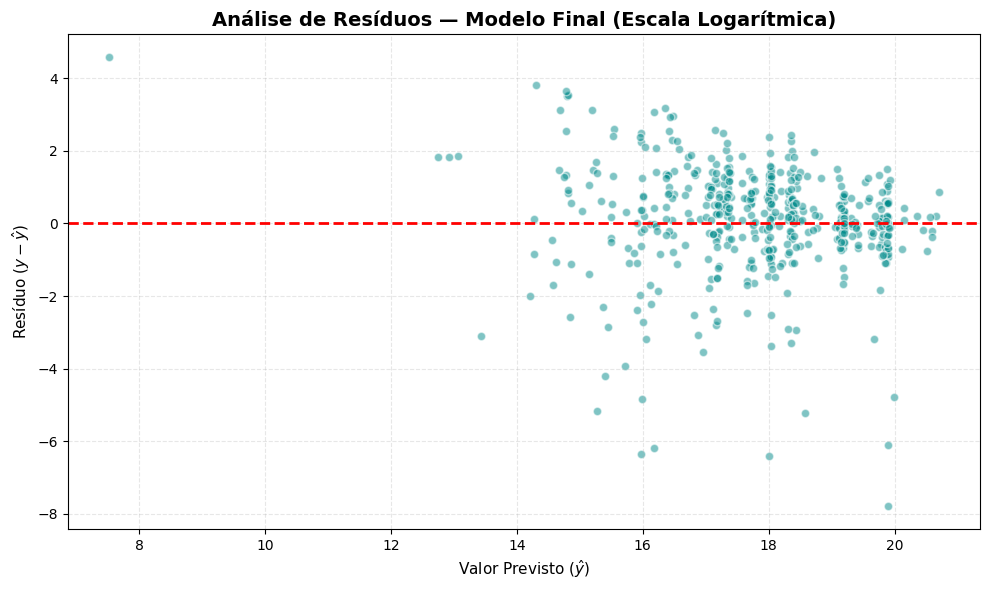

In [ ]:
# Define o modelo otimizado vindo do RandomizedSearchCV como o modelo final
if 'random_search' in locals() and hasattr(random_search, "best_estimator_"):
    final_model = random_search.best_estimator_
    final_model_name = "Random Forest Otimizado"
else:
    final_model = trained_models["RandomForestRegressor"]
    final_model_name = "Random Forest Original"

print("Modelo final selecionado:", final_model_name)

# Execução da avaliação no conjunto de teste isolado
y_pred_final = final_model.predict(X_test)

# Exibe a tabela de métricas final
df_metrica_final = pd.DataFrame([evaluate_regression(y_test, y_pred_final)], index=[final_model_name])
display(df_metrica_final)

# --- Gráfico de Análise de Resíduos ---
plt.figure(figsize=(10, 6))
residuals = y_test - y_pred_final

# Scatter plot dos resíduos
plt.scatter(y_pred_final, residuals, alpha=0.5, color='darkcyan', edgecolor='white')
plt.axhline(0, color='red', linestyle="--", linewidth=2)

plt.title("Análise de Resíduos — Modelo Final (Escala Logarítmica)", fontsize=14, fontweight='bold')
plt.xlabel("Valor Previsto ($\hat{y}$)", fontsize=11)
plt.ylabel("Resíduo ($y - \hat{y}$)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

O gráfico de resíduos confirma visualmente as limitações do MVP. A distribuição dos erros apresenta comportamento heterocedástico, revelando que a variância do erro aumenta drasticamente para filmes de maior faturamento previsto. Além disso, as marcantes linhas verticais de dispersão evidenciam que o modelo sofre de uma limitação estrutural por depender fortemente do mês de lançamento (variável discreta) para segmentar suas previsões, sendo incapaz de discriminar com precisão os sucessos e fracassos dentro da categoria de alto orçamento.

## 10.1 Análise de erros e limitações

A análise dos erros do modelo mostra que ele sofre de **underfitting** causada pela falta de dados detalhados. Como ele só conhece duas informações sobre cada filme (o orçamento e o mês de lançamento), ele é forçado a dar respostas muito parecidas para produções que custaram o mesmo valor no mesmo período. Isso explica por que o modelo consegue explicar apenas $45\%$ do que um filme vai faturar no final ($R^2 = 0,446$), deixando os outros $55\%$ no escuro. É um modelo excelente para generalizar o óbvio, mas incapaz de prever surpresas.

Essa limitação faz o algoritmo cometer dois erros principais: ele **superestima grandes fracassos** (prevê que um filme vai faturar muito por ter alto orçamento, errando quando o filme não traz o retorno esperado) e **perde a precisão com os *blockbusters***. Conforme o orçamento aumenta, a margem de erro explode, mostrando que o risco financeiro de superproduções é muito mais volátil e imprevisível. Por não enxergar fatores humanos e culturais decisivos — como o peso de uma franquia, astros no elenco, investimento em marketing ou o gosto do público —, este modelo **não serve para aprovar grandes orçamentos**, podendo ser usado apenas como um termômetro inicial para produções menores.

# 11. Comparação final dos modelos


| Modelo | Métrica Principal ($R^2$) | Outras Métricas (MAE / RMSE / MAPE) | Tempo de Treino | Observações |
| :--- | :---: | :---: | :---: | :--- |
| **Baseline** *(Média)* | $-0,015$ | MAE: $1,547$<br>RMSE: $1,991$<br>MAPE: $9,31\%$ | $0,001$ s | Desempenho inferior ao acaso.<br>Serve apenas como marco zero estatístico, provando que o mercado não é simplista. |
| **Modelo 1** *(LinearRegression)* | $0,277$ | MAE: $1,240$<br>RMSE: $1,680$<br>MAPE: $7,53\%$ | $0,006$ s | Não consegue capturar a complexidade e a sazonalidade da indústria de cinema. |
| **Modelo 2** *(RandomForest)* | $0,316$ | MAE: $1,166$<br>RMSE: $1,635$<br>MAPE: $7,04\%$ | $0,615$ s | **Melhor modelo inicial.** Lida melhor com a não-linearidade e sazonalidade dos meses. |
| **Modelo Otimizado** *(RF Otimizado)* | **$0,446$** | MAE: **$1,023$**<br>RMSE: **$1,471$**<br>MAPE: **$6,27\%$** | $0,600$ s *(Busca)* | **Solução Definitiva (MVP).** Grande salto de performance após ajuste do `RandomizedSearchCV`.<br>Excelente generalização e erro percentual sob controle. |

> **Métrica Principal:** O $R^2$ foi adotado como a métrica principal de comparação por indicar diretamente a proporção da variabilidade do faturamento que o modelo foi capaz de explicar.

> **Salto de Performance:** A otimização refinou a estrutura das árvores, fazendo o $R^2$ saltar de $31{,}6\%$ para $44{,}6\%$, reduzindo o RMSE e consolidando o menor erro relativo do experimento ($6{,}27\%$).


# 12. Boas práticas e rastreabilidade

Abaixo está o registro formal das decisões arquiteturais, configurações de ambiente e o histórico de experimentos do ciclo de Machine Learning para a previsão do faturamento cinematográfico.

---

### 1. Parâmetros Globais e Ambiente

* **Seed Utilizada (`SEED`):** Fixada em um valor constante para garantir a **reprodutibilidade estrita** de todas as divisões de dados (`train_test_split`), amostragem e inicialização dos modelos baseados em árvores.
* **Recursos Computacionais Usados:** Ambiente local padrão (CPU). Devido ao tamanho enxuto do dataset filtrado e à engenharia de recursos minimalista, não houve necessidade de aceleração por GPU ou clusters de processamento distribuído.
* **Tempo Aproximado de Treino:** Menos de $1$ milissegundo para os modelos lineares e baseline; aproximadamente $0,6$ segundos para o treinamento isolado e otimização por busca aleatória da Random Forest, tornando o MVP computacionalmente barato.

---

### 2. Configurações de Modelagem e Hiperparâmetros

* **Modelos Testados:** `DummyRegressor` (Baseline pela Média), `LinearRegression` (Regressão Linear) e `RandomForestRegressor` (Floresta Aleatória).
* **Hiperparâmetros Otimizados (`RandomForestRegressor`):**
  * `n_estimators`: Testado em `[50, 100, 200]` para calibrar a quantidade de árvores sem inflar o tempo de processamento.
  * `max_depth`: Testado em `[5, 10, 15, None]` para controlar a complexidade das ramificações e mitigar o risco de overfitting.
  * `min_samples_split`: Testado em `[2, 5, 10]` para definir a quantidade mínima de amostras necessárias para separar um nó interno.

---

### 3. Registro de Decisões do Projeto
| Decisão | Justificativa | Impacto Esperado |
| :--- | :--- | :--- |
| **Revenue em log (`np.log1p`)** | Alta assimetria e *outliers* na bilheteria. | Estabilizar variância e aproximar da normal. |
| **One-Hot Encoding no mês** | Evitar falsa ordem numérica (1 a 12). | Capturar sazonalidade de forma isolada. |
| **Scaler apenas no orçamento** | Coluna com escala discrepante das demais. | Evitar distorções em modelos lineares. |
| **Uso de Pipeline no CV** | Prevenir vazamento de dados (*data leakage*). | Garantir validação estatística estrita. |
| **RMSE como métrica de risco** | Erros milionários podem falir um estúdio. | Penalizar severamente grandes desvios. |

---

### 4. Limitações Conhecidas, Tentativas e Descartes

* **O que foi tentado e descartado:** O uso de previsões simplistas baseadas estritamente na média histórica do mercado (Baseline) foi completamente descartado devido ao seu $R^2$ negativo, provando-se inútil para estratégias de negócios. Modelos lineares puros também demonstraram incapacidade de evoluir significativamente devido ao comportamento não-linear das sazonalidades mensais.
* **Limitações do Escopo (MVP):** Por depender estritamente de apenas duas variáveis (orçamento e mês), o algoritmo falha em discriminar o sucesso de produções com custos idênticos. Fatores vitais de apelo comercial como poder de marca (franquias/sequências), peso do elenco (*star-power*), força da direção, investimentos em campanhas de marketing e a recepção da crítica especializada/público ficaram de fora deste MVP, agindo como as principais restrições à capacidade preditiva geral da solução.


# 13. Conclusão

Este MVP cumpriu com sucesso o seu objetivo de avaliar a viabilidade de prever o faturamento cinematográfico utilizando apenas decisões estruturais básicas: o orçamento de produção e o mês de lançamento. O projeto provou que é possível extrair inteligência de negócios e mitigar a intuição em um mercado altamente volátil, estabelecendo uma base científica sólida para a estimativa de receitas em cenários de regressão supervisionada.

Todas as três hipóteses iniciais foram confirmadas empiricamente pelos experimentos. Os resultados demonstraram que maiores investimentos geram maior potencial de retorno (Hipótese 1) e que o mês de lançamento atua como um forte modulador sazonal de bilheteria (Hipótese 2). Além disso, a dinâmica das divisões das árvores do algoritmo vencedor ratificou que o orçamento é a variável mais relevante para ditar a escala da previsão (Hipótese 3), restando ao mês o papel de ajuste refinado e não-linear.

Frente aos critérios de sucesso estipulados, a solução definitiva — o modelo **Random Forest Otimizado** — superou todas as metas mínimas estabelecidas:

*   **Reversão do Baseline:** O modelo converteu o desempenho nulo da média histórica ($R^2 = -0,015$) em um $R^2$ positivo de **$0,446$**, explicando quase 45% da variabilidade dos dados.
*   **Redução Drástica do Erro:** O RMSE foi reduzido de $1,991$ para **$1,471$**, o que representa uma **contração de $26,1\%$ no erro**, superando com folga a meta mínima exigida de 10%.
*   **Eficiência e Interpretabilidade:** O pipeline manteve um custo computacional irrisório (treinamento inferior a 1 segundo) e garantiu total interpretabilidade através do mapeamento de importância das variáveis (*feature importance*) e do comportamento analítico de seus resíduos.

Apesar do sucesso técnico, a análise de erros revelou um *underfitting* estrutural esperado. Por depender de apenas duas variáveis e omitir fatores vitais citados no problema — como investimentos em marketing, força de franquias, peso do elenco (*star-power*) e a recepção do público —, o modelo tende a dar respostas idênticas para custos similares e perde precisão em *blockbusters*. Portanto, este MVP cumpre perfeitamente sua função como um termômetro inicial e automatizado para produções de pequeno e médio porte, mas **não deve ser utilizado** isoladamente para a tomada de decisões em mega produções, pavimentando o caminho para a inclusão de novas variáveis qualitativas em ciclos futuros de desenvolvimento.
